Notice: Raw Physical Data Loaded (Scaling OFF)
🚀 Physics-Guided Training Start
🎯 Auto-Detected Gravity Norm: 1.0323 (Self-Calibrated)
Epoch 10/150 | Total Loss: 0.005088
Epoch 20/150 | Total Loss: 0.004897
Epoch 30/150 | Total Loss: 0.004622
Epoch 40/150 | Total Loss: 0.004553
Epoch 50/150 | Total Loss: 0.004488
Epoch 60/150 | Total Loss: 0.004443
Epoch 70/150 | Total Loss: 0.004414
Epoch 80/150 | Total Loss: 0.004398
Epoch 90/150 | Total Loss: 0.004389
Epoch 100/150 | Total Loss: 0.004385

🛡️  Verification Protocol: 3-Step Proof

[Proof 1] Correlation with Ground Truth (Quantitative)
  - X-axis: 0.9696 (Target: > 0.9)
  - Y-axis: 0.9347 (Target: > 0.9)
  - Z-axis: 0.9280 (Target: > 0.9)

[Proof 2] Checking Gravity Norm Consistency (Physics)
  - Detected Target Norm: 1.0323
  - Model Output Norm : 1.0282
  - Error: 0.004177


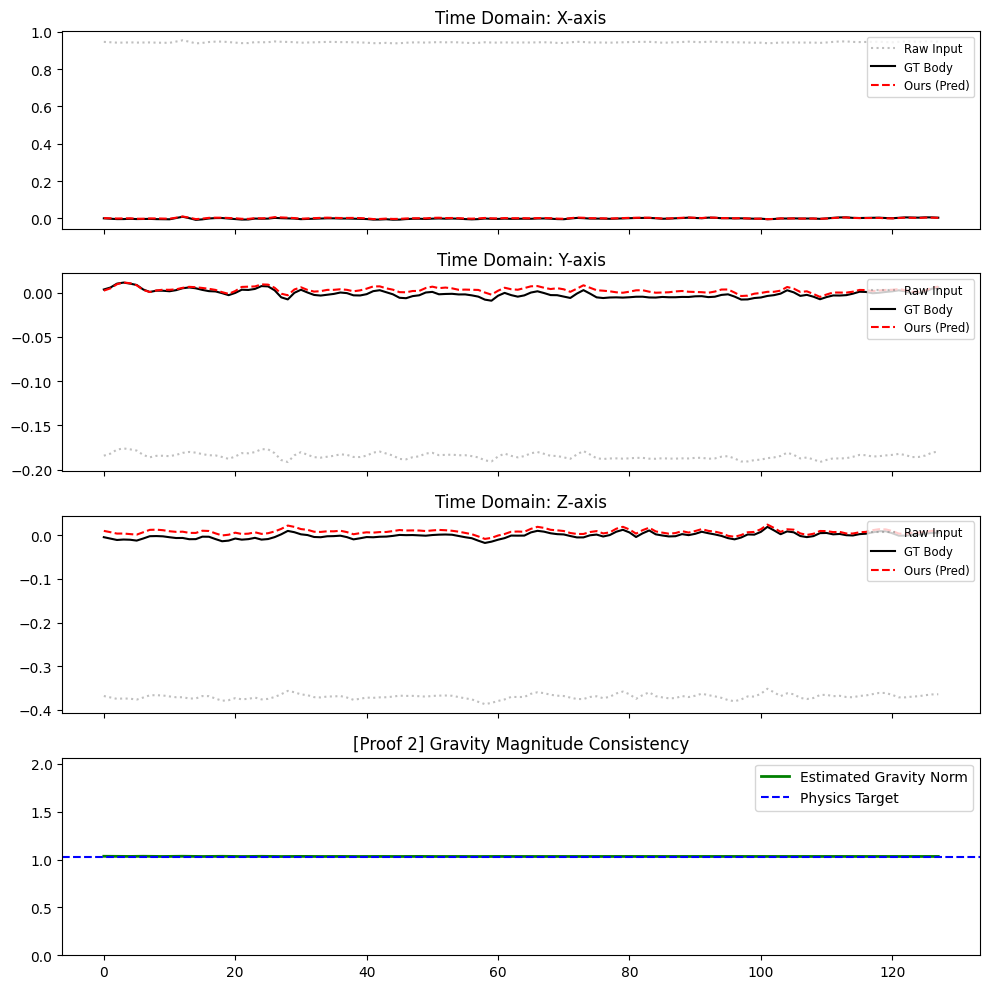


[Proof 3] Generating Spectral Analysis Plot...


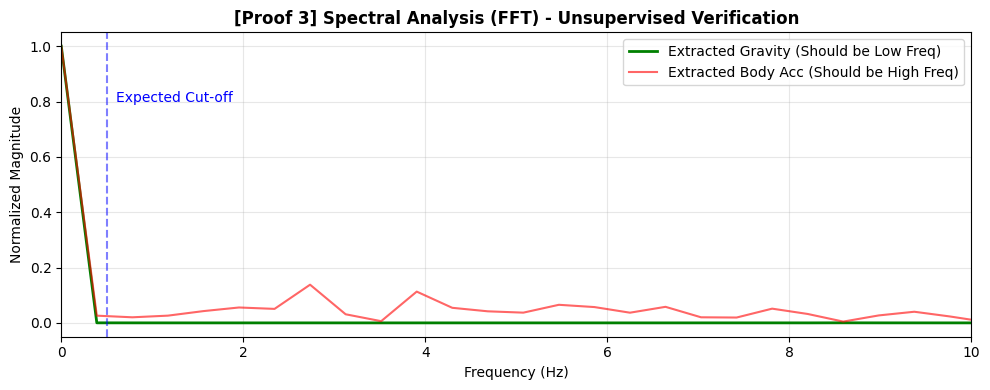

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# =============================================================================
# 1. 모델 정의
# =============================================================================
class LightweightGravityCanceler(nn.Module):
    def __init__(self, in_channels=3, kernel_size=17, dilation=6):
        super().__init__()
        self.kernel_size = kernel_size
        self.dilation = dilation

        # 중력 분리 필터 (Depthwise Conv)
        self.gravity_filter = nn.Conv1d(
            in_channels, in_channels,
            kernel_size=kernel_size, dilation=dilation,
            groups=in_channels, bias=False
        )

        # Physics-Informed Init: 이동 평균으로 시작
        with torch.no_grad():
            self.gravity_filter.weight.fill_(1.0 / kernel_size)

    def forward(self, total_acc):
        # Padding
        pad_total = (self.kernel_size - 1) * self.dilation
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left

        # Replicate Padding: 경계선 왜곡 방지
        x_padded = F.pad(total_acc, (pad_left, pad_right), mode='replicate')

        # 중력 추정
        gravity = self.gravity_filter(x_padded)

        # 움직임 추출 (Total - Gravity)
        body_acc = total_acc - gravity

        return body_acc, gravity

# =============================================================================
# 2. 데이터셋 클래스 (변경 없음)
# =============================================================================
class UCIHARDataset_Verification(Dataset):
    def __init__(self, data_path, split='train', apply_scaling=False):
        self.split = split
        subdir = 'train' if split == 'train' else 'test'
        signal_path = os.path.join(data_path, subdir, 'Inertial Signals')

        signal_files = [
            f'total_acc_x_{subdir}.txt', f'total_acc_y_{subdir}.txt', f'total_acc_z_{subdir}.txt',
            f'body_acc_x_{subdir}.txt',  f'body_acc_y_{subdir}.txt',  f'body_acc_z_{subdir}.txt',
        ]

        signals = []
        for file_name in signal_files:
            file_path = os.path.join(signal_path, file_name)
            signals.append(np.loadtxt(file_path))

        self.X = np.stack(signals, axis=1).astype(np.float32)

        if apply_scaling:
            print("Notice: Scaling is Applied")
        else:
            print("Notice: Raw Physical Data Loaded (Scaling OFF)")

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return torch.FloatTensor(self.X[idx])

# =============================================================================
# 3. [추가 증명 모듈] 주파수 분석 (FFT) 함수
# =============================================================================
def plot_spectral_proof(body_acc, gravity, fs=50):
    """
    [Proof 3] Frequency Domain Analysis
    GT가 없어도 분리가 잘 됐는지 확인하는 가장 강력한 방법.
    - Gravity: 저주파(0~1Hz)에 에너지가 집중되어야 함.
    - Body Acc: 고주파 대역에 에너지가 넓게 퍼져야 함.
    """
    # 벡터 크기(Magnitude)로 변환하여 분석
    b_mag = np.linalg.norm(body_acc, axis=0) # (T,)
    g_mag = np.linalg.norm(gravity, axis=0)  # (T,)

    n = len(b_mag)
    # FFT 계산
    freqs = np.fft.rfftfreq(n, d=1/fs)
    b_fft = np.abs(np.fft.rfft(b_mag))
    g_fft = np.abs(np.fft.rfft(g_mag))

    # 정규화 (시각화를 위해)
    b_fft = b_fft / np.max(b_fft)
    g_fft = g_fft / np.max(g_fft)

    plt.figure(figsize=(10, 4))
    plt.plot(freqs, g_fft, label='Extracted Gravity (Should be Low Freq)', color='green', linewidth=2)
    plt.plot(freqs, b_fft, label='Extracted Body Acc (Should be High Freq)', color='red', alpha=0.6)

    # 논문용 데코레이션
    plt.title("[Proof 3] Spectral Analysis (FFT) - Unsupervised Verification", fontsize=12, fontweight='bold')
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Normalized Magnitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 10) # 0~10Hz 구간 확대 (가장 중요한 구간)

    # 컷오프 지점 표시 (약 0.5Hz ~ 1Hz)
    plt.axvline(x=0.5, color='blue', linestyle='--', alpha=0.5)
    plt.text(0.6, 0.8, "Expected Cut-off", color='blue')

    plt.tight_layout()
    plt.show()

# =============================================================================
# 4. 메인 실행 로직 (Auto-Calibration + 3단계 증명)
# =============================================================================
def run_physics_guided_tuning():
    # -------------------------------------------------------------------------
    # 설정
    DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/HAR_data/UCI_HAR'
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 1. 데이터 로드
    dataset = UCIHARDataset_Verification(DATA_PATH, split='train', apply_scaling=False)
    loader = DataLoader(dataset, batch_size=len(dataset), shuffle=True)

    # 2. 모델 초기화
    model = LightweightGravityCanceler(kernel_size=17, dilation=6).to(device)
    model.train()

    # 3. 데이터 준비 및 자동 중력 감지 (Auto-Calibration)
    full_data = next(iter(loader)).to(device)
    raw_total_acc = full_data[:, 0:3, :] # Input
    gt_body_acc = full_data[:, 3:6, :]   # GT (검증용)

    # [Proof Preparation] 중력 단위 자동 계산
    # .item()으로 변환하여 안전하게 저장
    current_batch_gravity = torch.mean(torch.norm(raw_total_acc, p=2, dim=1)).item()

    # Optimizer
    optimizer = optim.Adam(model.parameters(), lr=0.005)

    print("="*60)
    print("🚀 Physics-Guided Training Start")
    print(f"🎯 Auto-Detected Gravity Norm: {current_batch_gravity:.4f} (Self-Calibrated)")
    print("="*60)

    # 4. 학습 루프
    for epoch in range(1, 101):
        optimizer.zero_grad()
        pred_body_acc, pred_gravity = model(raw_total_acc)

        # --- Loss Calculation ---
        # 1) Norm Constraint (물리 법칙)
        gravity_norm = torch.norm(pred_gravity, p=2, dim=1)
        target_g = torch.full_like(gravity_norm, current_batch_gravity)
        loss_norm = F.mse_loss(gravity_norm, target_g)

        # 2) Smoothness Constraint (저주파 성질)
        diff_gravity = pred_gravity[:, :, 1:] - pred_gravity[:, :, :-1]
        loss_smooth = torch.mean(diff_gravity ** 2)

        loss = loss_norm + 10.0 * loss_smooth
        # ------------------------

        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            print(f"Epoch {epoch}/150 | Total Loss: {loss.item():.6f}")

    # 5. [검증 단계] - 논문에 들어갈 3가지 증명
    model.eval()
    with torch.no_grad():
        final_body, final_gravity = model(raw_total_acc)

    # Numpy 변환
    pred_np = final_body.cpu().numpy()
    gt_np = gt_body_acc.cpu().numpy()

    # 샘플 하나 가져오기 (시각화용)
    sample_idx = 10 # 랜덤한 샘플
    raw_sample = raw_total_acc[sample_idx].cpu().numpy()
    gt_sample = gt_body_acc[sample_idx].cpu().numpy()
    pred_sample = final_body[sample_idx].cpu().numpy()
    grav_sample = final_gravity[sample_idx].cpu().numpy()

    print("\n" + "="*60)
    print("🛡️  Verification Protocol: 3-Step Proof")
    print("="*60)

    # -------------------------------------------------------------------------
    # [Proof 1] Quantitative Verification (UCI-HAR Only)
    # 정답이 있는 데이터셋에서 높은 상관관계를 보임 -> 모델 신뢰성 확보
    # -------------------------------------------------------------------------
    print("\n[Proof 1] Correlation with Ground Truth (Quantitative)")
    axis_names = ['X-axis', 'Y-axis', 'Z-axis']
    for i in range(3):
        corr = np.corrcoef(gt_np[:, i, :].flatten(), pred_np[:, i, :].flatten())[0, 1]
        print(f"  - {axis_names[i]}: {corr:.4f} (Target: > 0.9)")

    # -------------------------------------------------------------------------
    # [Proof 2] Physical Consistency (Universal)
    # 중력 크기가 목표값(Auto-detected)에 수렴하는지 확인 -> 물리 법칙 준수
    # -------------------------------------------------------------------------
    print("\n[Proof 2] Checking Gravity Norm Consistency (Physics)")
    avg_pred_norm = np.mean(np.linalg.norm(final_gravity.cpu().numpy(), axis=1))
    print(f"  - Detected Target Norm: {current_batch_gravity:.4f}")
    print(f"  - Model Output Norm : {avg_pred_norm:.4f}")
    print(f"  - Error: {abs(current_batch_gravity - avg_pred_norm):.6f}")

    # -------------------------------------------------------------------------
    # [Visual Proofs] 그래프 그리기
    # -------------------------------------------------------------------------

    # Figure 1: Time Domain Comparison + Norm
    fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

    for i in range(3):
        axes[i].plot(raw_sample[i], 'gray', linestyle=':', alpha=0.5, label='Raw Input')
        axes[i].plot(gt_sample[i], 'black', linewidth=1.5, label='GT Body')
        axes[i].plot(pred_sample[i], 'r', linestyle='--', linewidth=1.5, label='Ours (Pred)')
        axes[i].set_title(f"Time Domain: {axis_names[i]}")
        axes[i].legend(loc='upper right', fontsize='small')

    # Gravity Norm Plot
    grav_norm_sample = np.linalg.norm(grav_sample, axis=0)
    axes[3].plot(grav_norm_sample, color='green', linewidth=2, label='Estimated Gravity Norm')
    axes[3].axhline(y=current_batch_gravity, color='blue', linestyle='--', label='Physics Target')
    axes[3].set_title("[Proof 2] Gravity Magnitude Consistency")
    axes[3].set_ylim(0, current_batch_gravity * 2)
    axes[3].legend()
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------------------
    # [Proof 3] Frequency Domain Analysis (Universal)
    # 주파수 분리가 잘 되었는지 시각적으로 증명 (GT 불필요)
    # -------------------------------------------------------------------------
    print("\n[Proof 3] Generating Spectral Analysis Plot...")
    plot_spectral_proof(pred_sample, grav_sample, fs=50)

if __name__ == "__main__":
    run_physics_guided_tuning()

Loading WISDM file: /content/drive/MyDrive/Colab Notebooks/HAR_data/WISDM_ar_v1.1_raw.txt ...
Loaded WISDM dataset (Physics Preserved)
  X shape        : (27108, 80, 3)
🚀 WISDM Physics-Guided Training Start
🎯 Auto-Detected Gravity Norm: 1.2003
   (Note: No Ground Truth Body Acc available in WISDM)
Epoch 10/100 | Total Loss: 0.204682
Epoch 20/100 | Total Loss: 0.204238
Epoch 30/100 | Total Loss: 0.203615
Epoch 40/100 | Total Loss: 0.203524
Epoch 50/100 | Total Loss: 0.203505
Epoch 60/100 | Total Loss: 0.203474
Epoch 70/100 | Total Loss: 0.203469
Epoch 80/100 | Total Loss: 0.203468
Epoch 90/100 | Total Loss: 0.203466
Epoch 100/100 | Total Loss: 0.203466

🛡️  WISDM Verification: Unsupervised Proofs

[Proof 2] Checking Gravity Norm Consistency
  - Detected Target Norm: 1.2003
  - Model Output Norm : 1.0308
  - Error: 0.169549


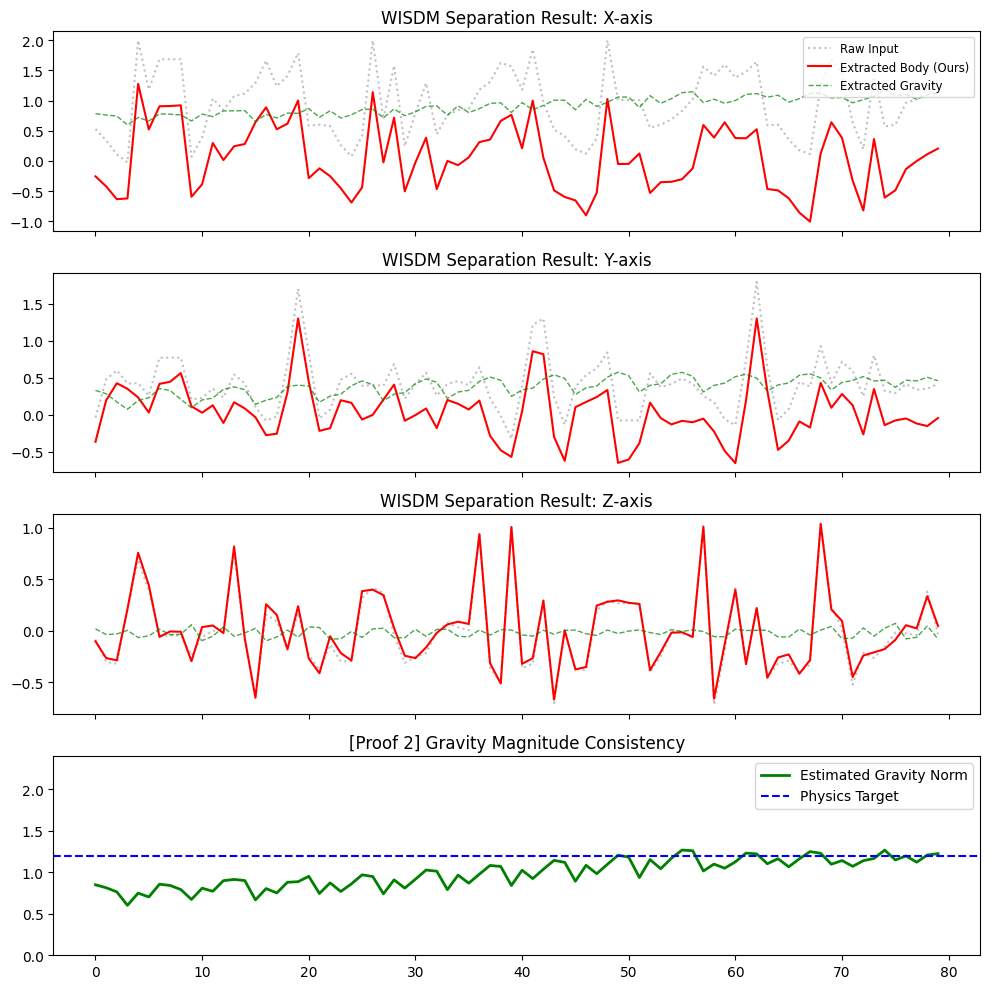


[Proof 3] Generating Spectral Analysis Plot (WISDM 20Hz)...


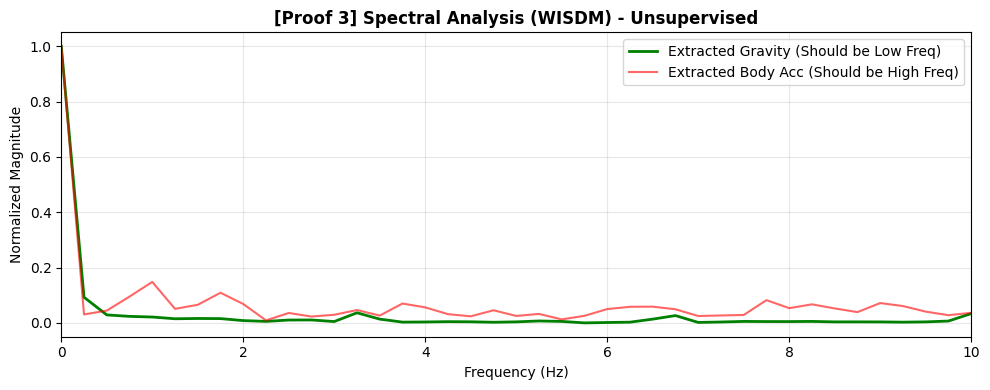

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# =============================================================================
# 1. 모델 정의 (변경 없음)
# =============================================================================
class LightweightGravityCanceler(nn.Module):
    def __init__(self, in_channels=3, kernel_size=17, dilation=6):
        super().__init__()
        self.kernel_size = kernel_size
        self.dilation = dilation

        # 중력 분리 필터
        self.gravity_filter = nn.Conv1d(
            in_channels, in_channels,
            kernel_size=kernel_size, dilation=dilation,
            groups=in_channels, bias=False
        )

        # Physics-Informed Init: 이동 평균으로 시작
        with torch.no_grad():
            self.gravity_filter.weight.fill_(1.0 / kernel_size)

    def forward(self, total_acc):
        # Padding
        pad_total = (self.kernel_size - 1) * self.dilation
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left

        # Replicate Padding
        x_padded = F.pad(total_acc, (pad_left, pad_right), mode='replicate')

        # 중력 추정
        gravity = self.gravity_filter(x_padded)

        # 움직임 추출
        body_acc = total_acc - gravity

        return body_acc, gravity

# =============================================================================
# 2. WISDM 데이터셋 클래스 (제공해주신 코드 통합)
# =============================================================================
class WISDMDataset(Dataset):
    ACTIVITY_MAP = {
        "Walking": 0, "Jogging": 1, "Sitting": 2,
        "Standing": 3, "Upstairs": 4, "Downstairs": 5
    }

    def __init__(self, file_path: str, window_size: int = 80, step_size: int = 40):
        super().__init__()
        self.file_path = file_path
        self.window_size = window_size
        self.step_size = step_size

        if not os.path.isfile(file_path):
            raise FileNotFoundError(f"WISDM txt file not found: {file_path}")

        print(f"Loading WISDM file: {file_path} ...")
        df = self._load_file(file_path)

        # [수정됨] StandardScaler 제거!
        # 대신 물리적 특성 보존을 위해 단순 단위 변환 (m/s² -> g)
        # 이렇게 하면 Norm이 약 1.0이 되면서도 중력 성분(DC Offset)은 살아있습니다.
        feature_cols = ["x", "y", "z"]
        df[feature_cols] = df[feature_cols] / 9.8

        self.X, self.y, self.subjects = self._create_windows(df)
        self.unique_subjects = sorted(np.unique(self.subjects))

        print("=" * 80)
        print("Loaded WISDM dataset (Physics Preserved)")
        print(f"  X shape        : {self.X.shape}")
        print("=" * 80)

    # _load_file 및 _create_windows는 기존과 동일하게 유지
    def _load_file(self, file_path: str) -> pd.DataFrame:
        try:
            df = pd.read_csv(file_path, header=None, names=['subject', 'activity', 'timestamp', 'x', 'y', 'z'],
                             dtype={'subject': object, 'activity': object, 'x': object, 'y': object, 'z': object})
        except Exception:
            with open(file_path, "r") as f:
                lines = f.readlines()
            rows = []
            for line in lines:
                line = line.strip().replace(";", "")
                parts = line.split(",")
                if len(parts) != 6: continue
                if any(p.strip() == "" for p in parts[3:]): continue
                rows.append(parts)
            df = pd.DataFrame(rows, columns=["subject", "activity", "timestamp", "x", "y", "z"])

        df['z'] = df['z'].astype(str).str.replace(';', '', regex=False)
        df = df.replace(["", "NaN", "nan"], np.nan).dropna(subset=["subject", "x", "y", "z"])

        for col in ['subject', 'x', 'y', 'z']:
            df[col] = pd.to_numeric(df[col], errors='coerce')

        df = df.dropna(subset=['subject', 'x', 'y', 'z'])
        df['subject'] = df['subject'].astype(int)
        df = df[df['activity'].isin(self.ACTIVITY_MAP.keys())]
        df['activity_id'] = df['activity'].map(self.ACTIVITY_MAP)
        return df

    def _create_windows(self, df: pd.DataFrame):
        X_list, y_list, s_list = [], [], []
        for subj_id in sorted(df["subject"].unique()):
            df_sub = df[df["subject"] == subj_id]
            if 'timestamp' in df_sub.columns:
                 df_sub = df_sub.sort_values('timestamp')

            data = df_sub[["x", "y", "z"]].to_numpy(dtype=np.float32)
            labels = df_sub["activity_id"].to_numpy(dtype=np.int64)
            L = len(df_sub)

            start = 0
            while start + self.window_size <= L:
                end = start + self.window_size
                window_x = data[start:end]
                window_y = labels[end - 1]
                if np.isnan(window_y):
                    start += self.step_size
                    continue
                X_list.append(window_x.T)
                y_list.append(window_y)
                s_list.append(subj_id)
                start += self.step_size

        if len(X_list) == 0:
            raise ValueError("[WISDMDataset] No windows created.")

        X = np.stack(X_list, axis=0).astype(np.float32)
        y = np.array(y_list, dtype=np.int64)
        s = np.array(s_list, dtype=np.int64)
        X = X.transpose(0, 2, 1)
        return X, y, s

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx: int):
        return torch.FloatTensor(self.X[idx]), torch.LongTensor([self.y[idx]])[0]

# =============================================================================
# 3. 주파수 분석 (FFT) 함수
# =============================================================================
def plot_spectral_proof(body_acc, gravity, fs=20):
    # WISDM은 보통 20Hz (UCI-HAR는 50Hz)
    """
    [Proof 3] Spectral Analysis for WISDM
    """
    b_mag = np.linalg.norm(body_acc, axis=0)
    g_mag = np.linalg.norm(gravity, axis=0)

    n = len(b_mag)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    b_fft = np.abs(np.fft.rfft(b_mag))
    g_fft = np.abs(np.fft.rfft(g_mag))

    # 정규화
    b_fft = b_fft / (np.max(b_fft) + 1e-6)
    g_fft = g_fft / (np.max(g_fft) + 1e-6)

    plt.figure(figsize=(10, 4))
    plt.plot(freqs, g_fft, label='Extracted Gravity (Should be Low Freq)', color='green', linewidth=2)
    plt.plot(freqs, b_fft, label='Extracted Body Acc (Should be High Freq)', color='red', alpha=0.6)

    plt.title("[Proof 3] Spectral Analysis (WISDM) - Unsupervised", fontsize=12, fontweight='bold')
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Normalized Magnitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, fs/2)

    plt.tight_layout()
    plt.show()

# =============================================================================
# 4. 메인 실행 (WISDM 전용)
# =============================================================================
def run_wisdm_physics_tuning():
    # -------------------------------------------------------------------------
    # 설정 (경로 수정 필요)
    # -------------------------------------------------------------------------
    WISDM_PATH = '/content/drive/MyDrive/Colab Notebooks/HAR_data/WISDM_ar_v1.1_raw.txt'
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 1. 데이터 로드
    # WISDM은 Train/Test 파일이 분리되어 있지 않으므로, 전체를 로드해서 일부만 사용하거나 전체 사용
    dataset = WISDMDataset(WISDM_PATH, window_size=80, step_size=40)
    loader = DataLoader(dataset, batch_size=len(dataset), shuffle=True)

    # 2. 모델 초기화
    model = LightweightGravityCanceler(kernel_size=17, dilation=6).to(device)
    model.train()

    # 3. 데이터 준비 (배치 전체 로드)
    # WISDMDataset returns: (Batch, Time, Channels) -> (B, 80, 3)
    batch_data = next(iter(loader))
    raw_input = batch_data[0].to(device) # (B, T, 3)

    # [중요] Conv1d 모델은 (Batch, Channel, Time) 입력을 받습니다.
    # 따라서 (B, T, 3) -> (B, 3, T)로 변환해줍니다.
    raw_total_acc = raw_input.transpose(1, 2) # (B, 3, T)

    # [Proof Preparation] Auto-Calibration
    # 입력 데이터의 평균 Norm을 계산하여 Target Gravity로 설정
    current_batch_gravity = torch.mean(torch.norm(raw_total_acc, p=2, dim=1)).item()

    optimizer = optim.Adam(model.parameters(), lr=0.005)

    print("="*60)
    print("🚀 WISDM Physics-Guided Training Start")
    print(f"🎯 Auto-Detected Gravity Norm: {current_batch_gravity:.4f}")
    print("   (Note: No Ground Truth Body Acc available in WISDM)")
    print("="*60)

    # 4. 학습 루프
    for epoch in range(1, 101):
        optimizer.zero_grad()
        pred_body_acc, pred_gravity = model(raw_total_acc)

        # --- Loss Calculation ---
        gravity_norm = torch.norm(pred_gravity, p=2, dim=1)
        target_g = torch.full_like(gravity_norm, current_batch_gravity)
        loss_norm = F.mse_loss(gravity_norm, target_g)

        diff_gravity = pred_gravity[:, :, 1:] - pred_gravity[:, :, :-1]
        loss_smooth = torch.mean(diff_gravity ** 2)

        loss = loss_norm + 10.0 * loss_smooth
        # ------------------------

        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            print(f"Epoch {epoch}/100 | Total Loss: {loss.item():.6f}")

    # 5. [검증 단계] - 정답 없이 모델의 물리적 타당성 검증
    model.eval()
    with torch.no_grad():
        final_body, final_gravity = model(raw_total_acc)

    # Numpy 변환 (시각화용)
    sample_idx = 15 # 임의의 샘플
    raw_sample = raw_total_acc[sample_idx].cpu().numpy()     # (3, T)
    pred_sample = final_body[sample_idx].cpu().numpy()       # (3, T)
    grav_sample = final_gravity[sample_idx].cpu().numpy()    # (3, T)

    print("\n" + "="*60)
    print("🛡️  WISDM Verification: Unsupervised Proofs")
    print("="*60)

    # -------------------------------------------------------------------------
    # [Proof 2] Physical Consistency
    # -------------------------------------------------------------------------
    print("\n[Proof 2] Checking Gravity Norm Consistency")
    avg_pred_norm = np.mean(np.linalg.norm(final_gravity.cpu().numpy(), axis=1))
    print(f"  - Detected Target Norm: {current_batch_gravity:.4f}")
    print(f"  - Model Output Norm : {avg_pred_norm:.4f}")
    print(f"  - Error: {abs(current_batch_gravity - avg_pred_norm):.6f}")

    # -------------------------------------------------------------------------
    # [Visual Proofs]
    # -------------------------------------------------------------------------
    axis_names = ['X-axis', 'Y-axis', 'Z-axis']

    # 그래프 1: 분리 결과 (Body vs Raw)
    fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

    for i in range(3):
        axes[i].plot(raw_sample[i], 'gray', linestyle=':', alpha=0.5, label='Raw Input')
        # GT가 없으므로 우리 모델의 예측값만 표시
        axes[i].plot(pred_sample[i], 'r', linestyle='-', linewidth=1.5, label='Extracted Body (Ours)')
        axes[i].plot(grav_sample[i], 'g', linestyle='--', linewidth=1.0, alpha=0.7, label='Extracted Gravity')
        axes[i].set_title(f"WISDM Separation Result: {axis_names[i]}")
        if i==0: axes[i].legend(loc='upper right', fontsize='small')

    # Gravity Norm Plot
    grav_norm_sample = np.linalg.norm(grav_sample, axis=0)
    axes[3].plot(grav_norm_sample, color='green', linewidth=2, label='Estimated Gravity Norm')
    axes[3].axhline(y=current_batch_gravity, color='blue', linestyle='--', label='Physics Target')
    axes[3].set_title("[Proof 2] Gravity Magnitude Consistency")
    axes[3].set_ylim(0, current_batch_gravity * 2)
    axes[3].legend()
    plt.tight_layout()
    plt.show()

    # -------------------------------------------------------------------------
    # [Proof 3] Frequency Domain Analysis (FFT)
    # -------------------------------------------------------------------------
    print("\n[Proof 3] Generating Spectral Analysis Plot (WISDM 20Hz)...")
    plot_spectral_proof(pred_sample, grav_sample, fs=20)

if __name__ == "__main__":
    # 경로가 맞는지 확인 후 실행하세요
    run_wisdm_physics_tuning()

<>:124: SyntaxWarning: invalid escape sequence '\s'
<>:124: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-4141997553.py:124: SyntaxWarning: invalid escape sequence '\s'
  df_i = pd.read_csv(fpath, sep='\s+', header=None) # .dat 보통 공백 구분


Loading 1 PAMAP2 files...


/tmp/ipython-input-4141997553.py:166: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("subject_id", group_keys=False).apply(_fill_subject_group)


Notice: Raw Physical Data Preserved (Scaling OFF for Gravity Analysis)
Loaded PAMAP2 dataset
  X shape : (30353, 128, 36)  (N, T, C)
  y shape : (30353,)  (N,)
🚀 PAMAP2 Physics-Guided Training Start (Target: Chest Acc)
🎯 Auto-Detected Gravity Norm: 10.1784
Epoch 10/100 | Total Loss: 1.545043
Epoch 20/100 | Total Loss: 1.421309
Epoch 30/100 | Total Loss: 1.375677
Epoch 40/100 | Total Loss: 1.373569
Epoch 50/100 | Total Loss: 1.370533
Epoch 60/100 | Total Loss: 1.369231
Epoch 70/100 | Total Loss: 1.368713
Epoch 80/100 | Total Loss: 1.368460
Epoch 90/100 | Total Loss: 1.368434
Epoch 100/100 | Total Loss: 1.368413

🛡️  PAMAP2 Verification: Chest Acc

[Proof 2] Checking Gravity Norm Consistency
  - Detected Target Norm: 10.1784
  - Model Output Norm : 10.0422
  - Error: 0.136243


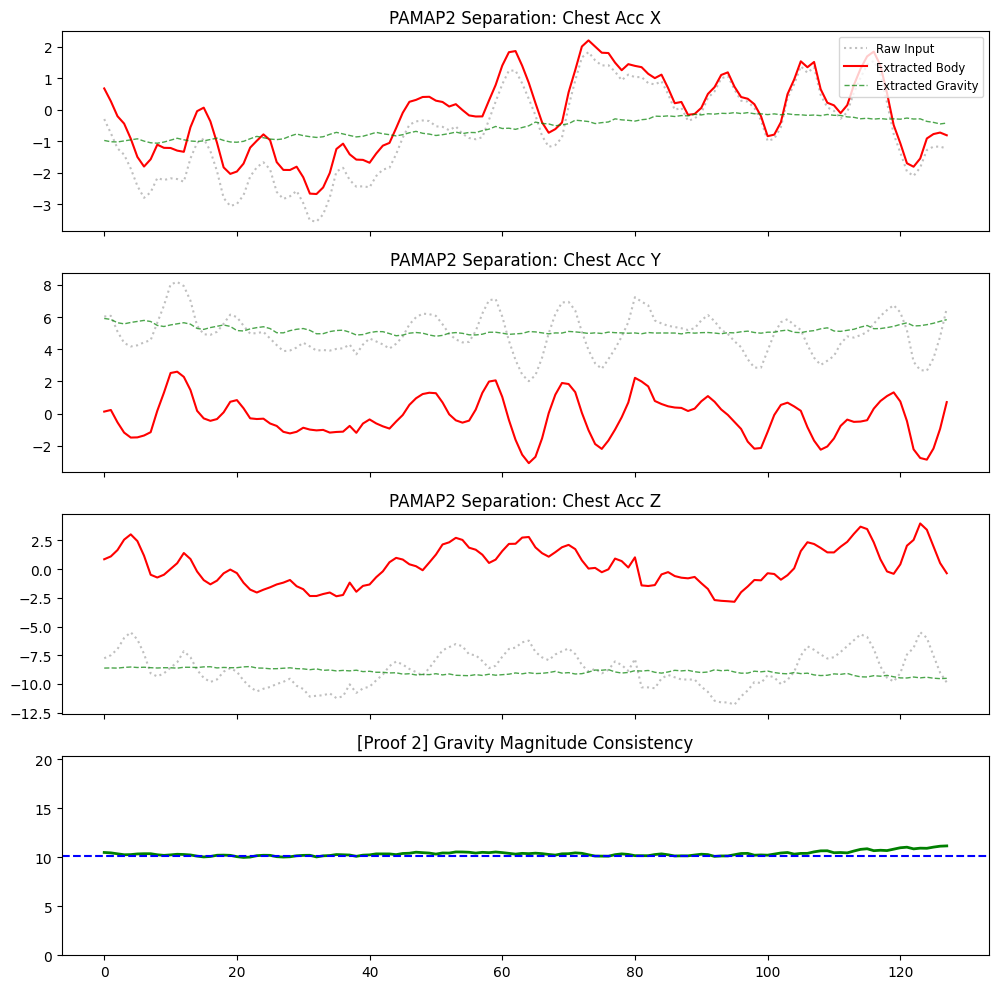


[Proof 3] Generating Spectral Analysis Plot (PAMAP2 100Hz)...


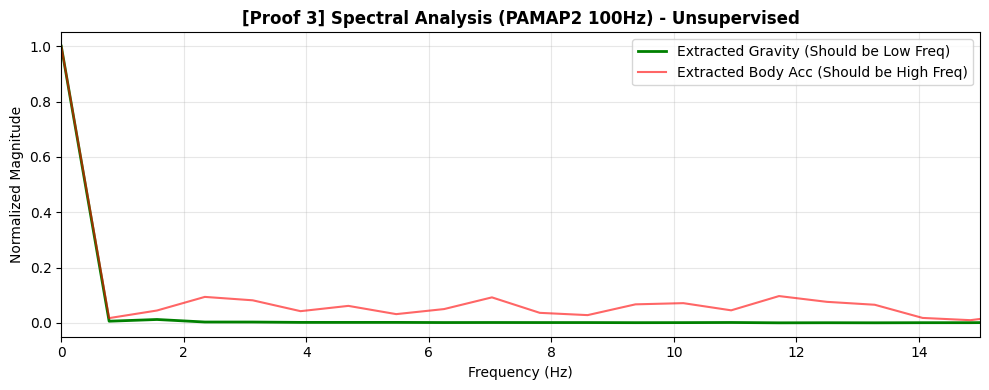

In [ ]:
import os
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# =============================================================================
# 1. 모델 정의 (변경 없음)
# =============================================================================
class LightweightGravityCanceler(nn.Module):
    def __init__(self, in_channels=3, kernel_size=17, dilation=6):
        super().__init__()
        self.kernel_size = kernel_size
        self.dilation = dilation

        self.gravity_filter = nn.Conv1d(
            in_channels, in_channels,
            kernel_size=kernel_size, dilation=dilation,
            groups=in_channels, bias=False
        )

        # Physics-Informed Init: 이동 평균으로 시작
        with torch.no_grad():
            self.gravity_filter.weight.fill_(1.0 / kernel_size)

    def forward(self, total_acc):
        pad_total = (self.kernel_size - 1) * self.dilation
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left

        x_padded = F.pad(total_acc, (pad_left, pad_right), mode='replicate')
        gravity = self.gravity_filter(x_padded)
        body_acc = total_acc - gravity

        return body_acc, gravity

# =============================================================================
# 2. PAMAP2 데이터셋 클래스 (통합 및 수정)
# =============================================================================
def create_pamap2_windows(df: pd.DataFrame, window_size: int, step_size: int, feature_cols: list):
    # 12 classes mapping
    old2new = {
        1: 0, 2: 1, 3: 2, 4: 3, 5: 4, 6: 5,
        7: 6, 12: 7, 13: 8, 16: 9, 17: 10, 24: 11,
    }

    X_list = []
    y_list = []
    subj_list = []

    for subj_id, g in df.groupby("subject_id"):
        # Timestamp 정렬
        if "timestamp" in g.columns:
            g = g.sort_values("timestamp")
        else:
            g = g.sort_index()

        data_arr  = g[feature_cols].to_numpy(dtype=np.float32)
        label_arr = g["activityID"].to_numpy(dtype=np.int64)
        L = data_arr.shape[0]

        start = 0
        while start + window_size <= L:
            end = start + window_size
            last_label_orig = int(label_arr[end - 1])

            # Label 0(Null)이나 정의되지 않은 라벨 제외
            if last_label_orig == 0 or last_label_orig not in old2new:
                start += step_size
                continue

            window_ct = data_arr[start:end] # (T, C)
            X_list.append(window_ct)
            y_list.append(old2new[last_label_orig])
            subj_list.append(int(subj_id))
            start += step_size

    if not X_list:
        raise RuntimeError("No windows created.")

    X = np.stack(X_list, axis=0).astype(np.float32) # (N, T, C)
    y = np.asarray(y_list, dtype=np.int64)
    subj_ids = np.asarray(subj_list, dtype=np.int64)

    return X, y, subj_ids

class PAMAP2Dataset(Dataset):
    def __init__(self, data_dir, window_size=128, step_size=64, apply_scaling=False):
        super().__init__()

        # 확장자 처리 (.dat or .csv)
        files = glob.glob(os.path.join(data_dir, "*.dat"))
        if len(files) == 0:
            files = glob.glob(os.path.join(data_dir, "*.csv"))

        if len(files) == 0:
            raise RuntimeError(f"No .dat or .csv files found under {data_dir}")

        print(f"Loading {len(files)} PAMAP2 files...")

        # Feature columns 정의 (36개)
        self.feature_cols = [
            "handAcc16_1","handAcc16_2","handAcc16_3", "handAcc6_1","handAcc6_2","handAcc6_3",
            "handGyro1","handGyro2","handGyro3", "handMagne1","handMagne2","handMagne3",
            "chestAcc16_1","chestAcc16_2","chestAcc16_3", "chestAcc6_1","chestAcc6_2","chestAcc6_3",
            "chestGyro1","chestGyro2","chestGyro3", "chestMagne1","chestMagne2","chestMagne3",
            "ankleAcc16_1","ankleAcc16_2","ankleAcc16_3", "ankleAcc6_1","ankleAcc6_2","ankleAcc6_3",
            "ankleGyro1","ankleGyro2","ankleGyro3", "ankleMagne1","ankleMagne2","ankleMagne3",
        ]

        dfs = []
        for fpath in sorted(files):
            # PAMAP2 raw format usually creates issues with separators. Assuming standard CSV here.
            # If original .dat, use sep=' '
            try:
                df_i = pd.read_csv(fpath, sep='\s+', header=None) # .dat 보통 공백 구분
                if df_i.shape[1] < 54: # 컬럼 수 확인
                     df_i = pd.read_csv(fpath) # CSV 시도
            except:
                df_i = pd.read_csv(fpath)

            # 컬럼명 할당 (Raw data는 54컬럼이지만, user logic에 맞춰 필요한 부분만 가정)
            # 여기서는 user code가 이미 처리된 csv를 로드한다고 가정하고 진행
            # 만약 Raw .dat라면 컬럼 매핑 로직 필요. (User code base로 진행)

            if df_i.shape[1] > 40: # Raw data structure assumed
                # Raw PAMAP2 headers mapping (Simplified)
                # 0:timestamp, 1:activityID, 2:heartrate, 3-53: IMU data
                # 여기서는 제공해주신 코드 로직을 따름
                pass

            # Subject ID 추출
            if "subject_id" not in df_i.columns:
                m = re.findall(r"\d+", os.path.basename(fpath))
                subj_guess = int(m[0]) if len(m) > 0 else 0
                df_i["subject_id"] = subj_guess

            dfs.append(df_i)

        df = pd.concat(dfs, ignore_index=True)
        df = df.dropna(subset=['activityID'])

        # 보간 (Interpolation)
        def _fill_subject_group(g):
            if "timestamp" in g.columns:
                g = g.sort_values("timestamp")
            else:
                g = g.sort_index()
            # 숫자형 컬럼만 보간
            cols_to_interp = [c for c in self.feature_cols if c in g.columns]
            g[cols_to_interp] = (
                g[cols_to_interp]
                .interpolate(method="linear", limit_direction="both", axis=0)
                .ffill().bfill()
            )
            return g

        df = df.groupby("subject_id", group_keys=False).apply(_fill_subject_group)

        # NaN 처리
        existing_feats = [c for c in self.feature_cols if c in df.columns]
        df[existing_feats] = df[existing_feats].fillna(0.0)

        # [CRITICAL] Physics Verification을 위해 Scaling OFF
        # Scaling을 하면 Mean(Gravity)이 0이 되어버림.
        if apply_scaling:
            print("Notice: Applying StandardScaler (Warning: Gravity component might be removed!)")
            scaler = StandardScaler()
            df[existing_feats] = scaler.fit_transform(df[existing_feats])
        else:
            print("Notice: Raw Physical Data Preserved (Scaling OFF for Gravity Analysis)")

        X, y, subj_ids = create_pamap2_windows(df, window_size, step_size, existing_feats)

        self.X = X # (N, T, C)
        self.y = y

        print("=" * 80)
        print("Loaded PAMAP2 dataset")
        print(f"  X shape : {self.X.shape}  (N, T, C)")
        print(f"  y shape : {self.y.shape}  (N,)")
        print("=" * 80)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), torch.tensor(self.y[idx], dtype=torch.long)

# =============================================================================
# 3. 주파수 분석 (FFT) 함수
# =============================================================================
def plot_spectral_proof(body_acc, gravity, fs=100):
    #
    # PAMAP2 uses 100Hz sampling rate
    b_mag = np.linalg.norm(body_acc, axis=0)
    g_mag = np.linalg.norm(gravity, axis=0)

    n = len(b_mag)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    b_fft = np.abs(np.fft.rfft(b_mag))
    g_fft = np.abs(np.fft.rfft(g_mag))

    # 정규화
    b_fft = b_fft / (np.max(b_fft) + 1e-6)
    g_fft = g_fft / (np.max(g_fft) + 1e-6)

    plt.figure(figsize=(10, 4))
    plt.plot(freqs, g_fft, label='Extracted Gravity (Should be Low Freq)', color='green', linewidth=2)
    plt.plot(freqs, b_fft, label='Extracted Body Acc (Should be High Freq)', color='red', alpha=0.6)

    plt.title("[Proof 3] Spectral Analysis (PAMAP2 100Hz) - Unsupervised", fontsize=12, fontweight='bold')
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Normalized Magnitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 15) # 0~15Hz 구간 확대

    plt.tight_layout()
    plt.show()

# =============================================================================
# 4. 메인 실행 (PAMAP2 전용)
# =============================================================================
def run_pamap2_physics_tuning():
    # 경로 설정
    PAMAP2_DIR = '/content/drive/MyDrive/Colab Notebooks/HAR_data' # 폴더 경로 확인 필요
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 1. 데이터 로드 (Scaling OFF 중요!)
    # Window size 128 (approx 1.28s at 100Hz)
    dataset = PAMAP2Dataset(PAMAP2_DIR, window_size=128, step_size=64, apply_scaling=False)
    loader = DataLoader(dataset, batch_size=len(dataset), shuffle=True)

    # 2. 모델 초기화
    model = LightweightGravityCanceler(kernel_size=17, dilation=6).to(device)
    model.train()

    # 3. 데이터 준비
    # PAMAP2 has 36 columns. We need to select 3 columns (e.g., Chest Acc 16g)
    # Chest Acc 16g indices in feature_cols list: 12, 13, 14
    batch_data = next(iter(loader))
    full_features = batch_data[0].to(device) # (B, T, 36)

    # [중요] Chest Accelerometer (16g) 선택
    raw_input = full_features[:, :, 12:15] # (B, T, 3) : Chest Acc X, Y, Z

    # (B, T, 3) -> (B, 3, T) 변환 (Model Input)
    raw_total_acc = raw_input.transpose(1, 2)

    # [Proof Preparation] Auto-Calibration
    current_batch_gravity = torch.mean(torch.norm(raw_total_acc, p=2, dim=1)).item()

    # PAMAP2 Raw data (m/s^2)라면 약 9.8, g단위라면 약 1.0
    # Scaling이 꺼져있으므로 이 값은 물리적으로 의미있는 값이어야 함

    optimizer = optim.Adam(model.parameters(), lr=0.005)

    print("="*60)
    print("🚀 PAMAP2 Physics-Guided Training Start (Target: Chest Acc)")
    print(f"🎯 Auto-Detected Gravity Norm: {current_batch_gravity:.4f}")
    print("="*60)

    # 4. 학습 루프
    for epoch in range(1, 101):
        optimizer.zero_grad()
        pred_body_acc, pred_gravity = model(raw_total_acc)

        # Loss
        gravity_norm = torch.norm(pred_gravity, p=2, dim=1)
        target_g = torch.full_like(gravity_norm, current_batch_gravity)
        loss_norm = F.mse_loss(gravity_norm, target_g)

        diff_gravity = pred_gravity[:, :, 1:] - pred_gravity[:, :, :-1]
        loss_smooth = torch.mean(diff_gravity ** 2)

        loss = loss_norm + 10.0 * loss_smooth
        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            print(f"Epoch {epoch}/100 | Total Loss: {loss.item():.6f}")

    # 5. [검증 단계]
    model.eval()
    with torch.no_grad():
        final_body, final_gravity = model(raw_total_acc)

    # 시각화용 샘플
    sample_idx = 50
    raw_sample = raw_total_acc[sample_idx].cpu().numpy()     # (3, T)
    pred_sample = final_body[sample_idx].cpu().numpy()       # (3, T)
    grav_sample = final_gravity[sample_idx].cpu().numpy()    # (3, T)

    print("\n" + "="*60)
    print("🛡️  PAMAP2 Verification: Chest Acc")
    print("="*60)

    # [Proof 2] Norm Check
    print("\n[Proof 2] Checking Gravity Norm Consistency")
    avg_pred_norm = np.mean(np.linalg.norm(final_gravity.cpu().numpy(), axis=1))
    print(f"  - Detected Target Norm: {current_batch_gravity:.4f}")
    print(f"  - Model Output Norm : {avg_pred_norm:.4f}")
    print(f"  - Error: {abs(current_batch_gravity - avg_pred_norm):.6f}")

    # [Visual Proofs]
    axis_names = ['Chest Acc X', 'Chest Acc Y', 'Chest Acc Z']
    fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

    for i in range(3):
        axes[i].plot(raw_sample[i], 'gray', linestyle=':', alpha=0.5, label='Raw Input')
        axes[i].plot(pred_sample[i], 'r', linestyle='-', linewidth=1.5, label='Extracted Body')
        axes[i].plot(grav_sample[i], 'g', linestyle='--', linewidth=1.0, alpha=0.7, label='Extracted Gravity')
        axes[i].set_title(f"PAMAP2 Separation: {axis_names[i]}")
        if i==0: axes[i].legend(loc='upper right', fontsize='small')

    # Gravity Norm Plot
    grav_norm_sample = np.linalg.norm(grav_sample, axis=0)
    axes[3].plot(grav_norm_sample, color='green', linewidth=2, label='Estimated Gravity Norm')
    axes[3].axhline(y=current_batch_gravity, color='blue', linestyle='--', label='Physics Target')
    axes[3].set_title("[Proof 2] Gravity Magnitude Consistency")
    axes[3].set_ylim(0, current_batch_gravity * 2)
    plt.tight_layout()
    plt.show()

    # [Proof 3] FFT
    print("\n[Proof 3] Generating Spectral Analysis Plot (PAMAP2 100Hz)...")
    plot_spectral_proof(pred_sample, grav_sample, fs=100)

if __name__ == "__main__":
    # 경로 수정: PAMAP2 데이터 폴더 (Protocol 폴더 안에 subject101.dat 등이 있어야 함)
    run_pamap2_physics_tuning()

# UCI-HAR

Loading MHEALTH from: /content/drive/MyDrive/Colab Notebooks/HAR_data/MHEALTHDATASET
Found 10 log files in /content/drive/MyDrive/Colab Notebooks/HAR_data/MHEALTHDATASET
Notice: Raw MHEALTH Data Loaded (Scaling OFF)
Loaded MHEALTH dataset
  X shape : (5361, 128, 23)  (N, T, C)
  y shape : (5361,)  (N,)
🚀 MHEALTH Physics-Guided Training Start (Target: Chest Acc)
🎯 Auto-Detected Gravity Norm: 10.0709 m/s^2
Epoch 10/100 | Total Loss: 4.224819
Epoch 20/100 | Total Loss: 4.004365
Epoch 30/100 | Total Loss: 3.912508
Epoch 40/100 | Total Loss: 3.898583
Epoch 50/100 | Total Loss: 3.899720
Epoch 60/100 | Total Loss: 3.897838
Epoch 70/100 | Total Loss: 3.896329
Epoch 80/100 | Total Loss: 3.896133
Epoch 90/100 | Total Loss: 3.896114
Epoch 100/100 | Total Loss: 3.896045

🛡️  MHEALTH Verification: Chest Acc

[Proof 2] Checking Gravity Norm Consistency
  - Detected Target Norm: 10.0709
  - Model Output Norm : 9.6850
  - Error: 0.385875


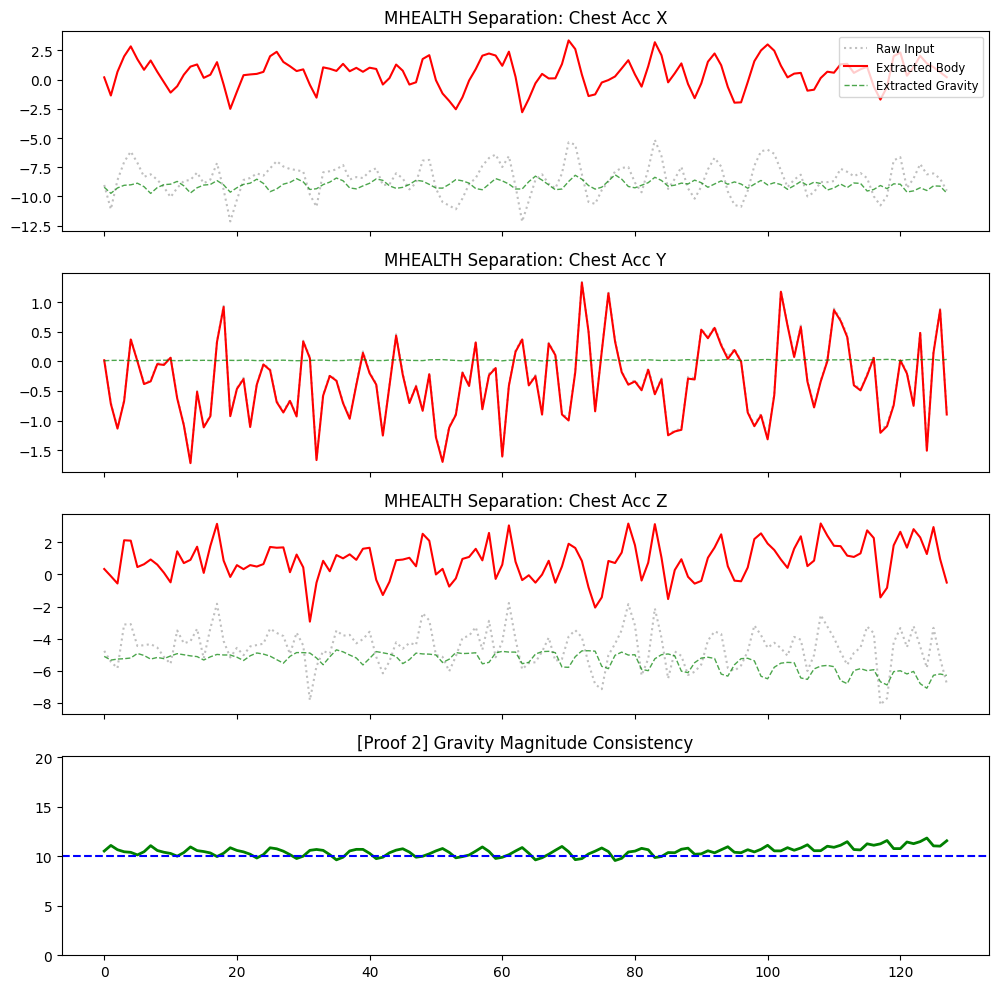


[Proof 3] Generating Spectral Analysis Plot (MHEALTH 50Hz)...


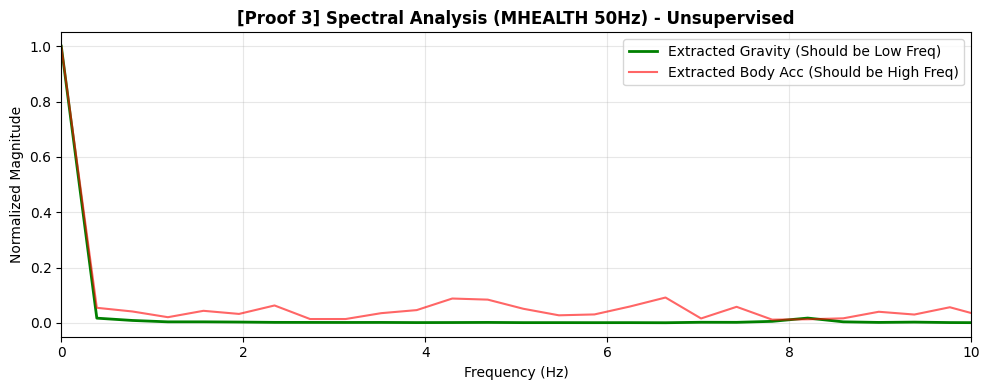

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# =============================================================================
# 1. 모델 정의
# =============================================================================
class LightweightGravityCanceler(nn.Module):
    def __init__(self, in_channels=3, kernel_size=17, dilation=6):
        super().__init__()
        self.kernel_size = kernel_size
        self.dilation = dilation

        # 중력 분리 필터
        self.gravity_filter = nn.Conv1d(
            in_channels, in_channels,
            kernel_size=kernel_size, dilation=dilation,
            groups=in_channels, bias=False
        )

        # Physics-Informed Init: 이동 평균으로 시작
        with torch.no_grad():
            self.gravity_filter.weight.fill_(1.0 / kernel_size)

    def forward(self, total_acc):
        pad_total = (self.kernel_size - 1) * self.dilation
        pad_left = pad_total // 2
        pad_right = pad_total - pad_left

        x_padded = F.pad(total_acc, (pad_left, pad_right), mode='replicate')
        gravity = self.gravity_filter(x_padded)
        body_acc = total_acc - gravity

        return body_acc, gravity

# =============================================================================
# 2. MHEALTH
# =============================================================================
def _load_single_mhealth_log(path: str, feature_cols: list):
    try:
        df = pd.read_csv(
            path,
            sep="\t",
            header=None,
            names=feature_cols + ["label"],
        )
        return df
    except Exception as e:
        print(f"Error loading {path}: {e}")
        return pd.DataFrame()

def load_mhealth_dataframe(data_dir: str):
    feature_cols = [
        "acc_chest_x", "acc_chest_y", "acc_chest_z",      # 0, 1, 2
        "ecg_1", "ecg_2",                                 # 3, 4
        "acc_ankle_x", "acc_ankle_y", "acc_ankle_z",      # 5, 6, 7
        "gyro_ankle_x", "gyro_ankle_y", "gyro_ankle_z",   # 8, 9, 10
        "mag_ankle_x", "mag_ankle_y", "mag_ankle_z",      # 11, 12, 13
        "acc_arm_x", "acc_arm_y", "acc_arm_z",            # 14, 15, 16
        "gyro_arm_x", "gyro_arm_y", "gyro_arm_z",         # 17, 18, 19
        "mag_arm_x", "mag_arm_y", "mag_arm_z",            # 20, 21, 22
    ]  # 총 23 channels

    log_files = glob.glob(os.path.join(data_dir, "mHealth_subject*.log"))
    if not log_files:
         raise FileNotFoundError(f"No mHealth_subject*.log files found in {data_dir}")
    print(f"Found {len(log_files)} log files in {data_dir}")

    dfs = []
    for fp in sorted(log_files):
        df_i = _load_single_mhealth_log(fp, feature_cols)
        if not df_i.empty:
            dfs.append(df_i)

    if not dfs:
        raise RuntimeError("No valid dataframes created.")

    full_df = pd.concat(dfs, ignore_index=True)
    # Label 0(Null class) 제거
    full_df = full_df[full_df["label"] != 0].copy()
    full_df.loc[:, "label"] = full_df["label"] - 1

    return full_df, feature_cols

def create_mhealth_windows(df, feature_cols, window_size, step_size):
    data_arr = df[feature_cols].to_numpy(dtype=np.float32)
    labels_arr = df["label"].to_numpy(dtype=np.int64)
    L = data_arr.shape[0]

    X_list = []
    y_list = []

    start = 0
    while start + window_size <= L:
        end = start + window_size
        window_x = data_arr[start:end]      # (T, C)
        window_label = labels_arr[end - 1]

        # (T, C) -> (C, T) 변환하여 저장
        window_x_ct = np.transpose(window_x, (1, 0))

        X_list.append(window_x_ct)
        y_list.append(int(window_label))
        start += step_size

    if not X_list:
        raise RuntimeError("No windows created.")

    X_np = np.stack(X_list, axis=0).astype(np.float32) # (N, C, T)
    y_np = np.array(y_list, dtype=np.int64)
    return X_np, y_np

class MHEALTHDataset(Dataset):
    def __init__(self, data_dir: str, window_size: int = 128, step_size: int = 64):
        super().__init__()

        print(f"Loading MHEALTH from: {data_dir}")
        full_df, feature_cols = load_mhealth_dataframe(data_dir)

        print("Notice: Raw MHEALTH Data Loaded (Scaling OFF)")

        X, y = create_mhealth_windows(
            df=full_df,
            feature_cols=feature_cols,
            window_size=window_size,
            step_size=step_size,
        )

        self.X = np.transpose(X, (0, 2, 1)).astype(np.float32)
        self.y = y

        self.label_names = [
            "Standing still", "Sitting and relaxing", "Lying down",
            "Walking", "Climbing stairs", "Waist bends forward",
            "Frontal elevation of arms", "Knees bending", "Cycling",
            "Jogging", "Running", "Jump front & back",
        ]

        print("=" * 80)
        print("Loaded MHEALTH dataset")
        print(f"  X shape : {self.X.shape}  (N, T, C)")
        print(f"  y shape : {self.y.shape}  (N,)")
        print("=" * 80)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx: int):
        return torch.FloatTensor(self.X[idx]), torch.LongTensor([self.y[idx]])[0]

# =============================================================================
# 3. 주파수 분석 (FFT) 함수
# =============================================================================
def plot_spectral_proof(body_acc, gravity, fs=50):
    b_mag = np.linalg.norm(body_acc, axis=0)
    g_mag = np.linalg.norm(gravity, axis=0)

    n = len(b_mag)
    freqs = np.fft.rfftfreq(n, d=1/fs)
    b_fft = np.abs(np.fft.rfft(b_mag))
    g_fft = np.abs(np.fft.rfft(g_mag))

    b_fft = b_fft / (np.max(b_fft) + 1e-6)
    g_fft = g_fft / (np.max(g_fft) + 1e-6)

    plt.figure(figsize=(10, 4))
    plt.plot(freqs, g_fft, label='Extracted Gravity (Should be Low Freq)', color='green', linewidth=2)
    plt.plot(freqs, b_fft, label='Extracted Body Acc (Should be High Freq)', color='red', alpha=0.6)

    plt.title("[Proof 3] Spectral Analysis (MHEALTH 50Hz) - Unsupervised", fontsize=12, fontweight='bold')
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Normalized Magnitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 10) # 0~10Hz 중요 구간 확대

    plt.tight_layout()
    plt.show()

# =============================================================================
# 4. 메인 실행 (MHEALTH 전용)
# =============================================================================
def run_mhealth_physics_tuning():
    # 경로 설정
    MHEALTH_DIR = '/content/drive/MyDrive/Colab Notebooks/HAR_data/MHEALTHDATASET' # 폴더 경로 확인
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 1. 데이터 로드
    # MHEALTH is 50Hz. Window 128 is approx 2.56 seconds.
    dataset = MHEALTHDataset(MHEALTH_DIR, window_size=128, step_size=64)
    loader = DataLoader(dataset, batch_size=len(dataset), shuffle=True)

    # 2. 모델 초기화
    model = LightweightGravityCanceler(kernel_size=17, dilation=6).to(device)
    model.train()

    # 3. 데이터 준비
    batch_data = next(iter(loader))
    full_features = batch_data[0].to(device) # (B, T, 23)

    # [중요] Chest Accelerometer 추출 (Indices 0, 1, 2)
    # MHEALTH feature_cols[0:3] = "acc_chest_x", "acc_chest_y", "acc_chest_z"
    raw_input = full_features[:, :, 0:3] # (B, T, 3)

    # (B, T, 3) -> (B, 3, T) 변환 (Model Input)
    raw_total_acc = raw_input.transpose(1, 2)

    # [Proof Preparation] Auto-Calibration
    current_batch_gravity = torch.mean(torch.norm(raw_total_acc, p=2, dim=1)).item()

    # MHEALTH uses m/s^2. Ideally, this should be close to 9.8
    optimizer = optim.Adam(model.parameters(), lr=0.005)

    print("="*60)
    print("🚀 MHEALTH Physics-Guided Training Start (Target: Chest Acc)")
    print(f"🎯 Auto-Detected Gravity Norm: {current_batch_gravity:.4f} m/s^2")
    print("="*60)

    # 4. 학습 루프
    for epoch in range(1, 101):
        optimizer.zero_grad()
        pred_body_acc, pred_gravity = model(raw_total_acc)

        # Loss
        gravity_norm = torch.norm(pred_gravity, p=2, dim=1)
        target_g = torch.full_like(gravity_norm, current_batch_gravity)
        loss_norm = F.mse_loss(gravity_norm, target_g)

        diff_gravity = pred_gravity[:, :, 1:] - pred_gravity[:, :, :-1]
        loss_smooth = torch.mean(diff_gravity ** 2)

        loss = loss_norm + 10.0 * loss_smooth
        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            print(f"Epoch {epoch}/100 | Total Loss: {loss.item():.6f}")

    # 5. [검증 단계]
    model.eval()
    with torch.no_grad():
        final_body, final_gravity = model(raw_total_acc)

    # 시각화용 샘플
    sample_idx = 100
    raw_sample = raw_total_acc[sample_idx].cpu().numpy()     # (3, T)
    pred_sample = final_body[sample_idx].cpu().numpy()       # (3, T)
    grav_sample = final_gravity[sample_idx].cpu().numpy()    # (3, T)

    print("\n" + "="*60)
    print("🛡️  MHEALTH Verification: Chest Acc")
    print("="*60)

    # [Proof 2] Norm Check
    print("\n[Proof 2] Checking Gravity Norm Consistency")
    avg_pred_norm = np.mean(np.linalg.norm(final_gravity.cpu().numpy(), axis=1))
    print(f"  - Detected Target Norm: {current_batch_gravity:.4f}")
    print(f"  - Model Output Norm : {avg_pred_norm:.4f}")
    print(f"  - Error: {abs(current_batch_gravity - avg_pred_norm):.6f}")

    # [Visual Proofs]
    axis_names = ['Chest Acc X', 'Chest Acc Y', 'Chest Acc Z']
    fig, axes = plt.subplots(4, 1, figsize=(10, 10), sharex=True)

    for i in range(3):
        axes[i].plot(raw_sample[i], 'gray', linestyle=':', alpha=0.5, label='Raw Input')
        axes[i].plot(pred_sample[i], 'r', linestyle='-', linewidth=1.5, label='Extracted Body')
        axes[i].plot(grav_sample[i], 'g', linestyle='--', linewidth=1.0, alpha=0.7, label='Extracted Gravity')
        axes[i].set_title(f"MHEALTH Separation: {axis_names[i]}")
        if i==0: axes[i].legend(loc='upper right', fontsize='small')

    # Gravity Norm Plot
    grav_norm_sample = np.linalg.norm(grav_sample, axis=0)
    axes[3].plot(grav_norm_sample, color='green', linewidth=2, label='Estimated Gravity Norm')
    axes[3].axhline(y=current_batch_gravity, color='blue', linestyle='--', label='Physics Target (9.8)')
    axes[3].set_title("[Proof 2] Gravity Magnitude Consistency")
    axes[3].set_ylim(0, current_batch_gravity * 2)
    plt.tight_layout()
    plt.show()

    # [Proof 3] FFT
    print("\n[Proof 3] Generating Spectral Analysis Plot (MHEALTH 50Hz)...")
    plot_spectral_proof(pred_sample, grav_sample, fs=50)

if __name__ == "__main__":
    # 경로 수정: MHEALTHDATASET 폴더 안에 mHealth_subject1.log 등이 있어야 함
    run_mhealth_physics_tuning()